In [1]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import csv
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math as math
# from matplotlib.ticker import LogFormatter
import itertools as it
from IPython.core.display import HTML
from fractions import Fraction
from copy import deepcopy


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [2]:
nh_min = 16
refRatio = 2
CFL = np.sqrt(0.5)
x_0 = 0.
x_1 = 0.5

dataPts = 5

L = 1
locs = [x_1]
epsilons = [1, 1] # [1, 1] # 
mus = [1, 1] # [1]#, 1] # 

func = WFT.Gauss#Packet
derivative = True
k = 13

test = 1
Fake = False
plot = False
rotate = False

In [3]:
sameTime = False # You usually want this False.
override = True # You usually want this True.

longTime = True # You usually want this False.

addOnStr = ''
if (longTime):
    sameTime = True
    override = False
    addOnStr = 'LongProp'

In [4]:
if (test == 1):
    AMR = False
    Uniform = True
    Two = False
    TestString = '1MedUniform' + addOnStr
    AMR1 = False
    AMR2 = False
    AM1 = 'A'
    AM2 = 'M'
    locs1 = []
    epsilons1 = [1] # [1, 1] # 
    mus1 = [1]
    locs2 = [x_1]
    epsilons2 = [1, 1] # [1, 1] # 
    mus2 = [1, 1]
    refRatio1 = 1
    refRatio2 = 1
    nt1 = 1
    nt2 = 1
    str1 = 'Uniform Advection'
    str2 = 'Uniform Maxwell'
else:
    if (test == 2):
        AMR = True
        Uniform = False
        Two = False
        TestString = '1MedLMR' + addOnStr
        AMR1 = True
        AMR2 = True
        AM1 = 'A'
        AM2 = 'M'
        locs1 = []
        epsilons1 = [1] 
        mus1 = [1]
        locs2 = [x_1]
        epsilons2 = [1, 1]
        mus2 = [1, 1]
        refRatio1 = 1
        refRatio2 = 1
        nt1 = 1#2
        nt2 = 1#2
        if (sameTime):
            nt1 = 2
            nt2 = 2
        str1 = 'LMR Advection'
        str2 = 'LMR Maxwell'
    else:
        AMR = True
        Uniform = True
        Two = True
        TestString = '2Med' + addOnStr
        AMR1 = False
        AMR2 = True
        AM1 = 'M'
        AM2 = 'M'
        locs1 = [x_1]
        epsilons1 = [1, 0.25]
        mus1 = [1, 1]
        locs2 = [x_1]
        epsilons2 = [1, 0.25]
        mus2 = [1, 1]
        refRatio1 = 1#2
        refRatio2 = 1
        nt1 = 1
        nt2 = 1#2
        if (sameTime):
            nt2 = 2
            if (not longTime):
                refRatio1 = 2
        str1 = 'Uniform Maxwell'
        str2 = 'LMR Maxwell'

In [5]:
factor = 1

if (func == WFT.Polynomial):
    polyorder = 1
    x_0 = 0
    coefs = 16 * np.ones(polyorder+1, float)
    coefs[0] = 0
    args = [x_0, coefs]
    tab = 'Polynomial'
else:
    sigma, mu = WFT.GaussParams(0, 0.5, deriv = derivative) # You switched 0.5 to 0.25.
    funcString = 'Gauss'
    if (func == WFT.Gauss):
        args = [sigma, mu]
        if (derivative):
            funcString = funcString + 'Deriv'
            factor = 10**-2
    else:
        args = [sigma, mu, k]
        funcString = funcString + 'Pack' + str(k)


funcString = funcString

print(sigma) # 0.02924930987844313 for before
             # 0.02924930987844313

0.02924930987844313


/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/WaveformTools.py:450: RuntimeWarning: divide by zero encountered in divide
  val1 = 10 ** (errOrd / (alphRange ** 2))
/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/WaveformTools.py:450: RuntimeWarning: overflow encountered in power
  val1 = 10 ** (errOrd / (alphRange ** 2))
/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/WaveformTools.py:451: RuntimeWarning: divide by zero encountered in divide
  val2 = ((10 ** errOrd) * errOrd * np.log(10)) / ((alphRange ** 2) * (x_1 - x_0))
/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/WaveformTools.py:452: RuntimeWarning: invalid value encountered in subtract
  transc = abs(np.ma.masked_invalid(val1 - val2, nan))


In [6]:
savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'
saveAppend = funcString + 'ConvergTest' + str(test)

In [7]:
omega0 = BT.Grid(nh_min)
physics1 = BT.PhysProps(omega0, epsilons1, mus1, locs1, L)
physics2 = BT.PhysProps(omega0, epsilons2, mus2, locs2, L)

In [8]:
c = physics1.cVec
cMat = physics1.cMat
c1 = c[0]
c2 = c[-1]

t = 0.25 * ((1 / c1) + (1 / c2)) # 1. / (2. * c1)
# if (test == 3):
#     t = (3. / (8. * c1)) + (1. / (4. * c2))
# else:
#     t = (3. / 8.) * ((1. / c1) + (1. / c2))
fact1 = nt1
fact2 = nt2


if (longTime):
    t1, nt1 = ST.CalcTime(omega0, CFL, cMat, t = t, override = False, refRatio = 1)
    t2, nt2 = ST.CalcTime(omega0, CFL, cMat, t = t, override = False, refRatio = 1)
    # nt1 = fact1 * nt1
    # nt2 = fact2 * nt2
    print(longTime)

print(t, t1, t2)

dx_min = 0.0625 dt = 0.04419417382415922
This is what's happening.
dx_min = 0.0625 dt = 0.04419417382415922
This is what's happening.
True
0.5 0.48613591206575146 0.48613591206575146


In [9]:
def GraphParams(Two, Uniform, AMR):
    if (Two):
        color1 = PT.ColorDefault(2)
        color2 = PT.ColorDefault(1)
        zorder1 = 2
        zorder2 = 3
        Advect = False
        if (Uniform):
            if (AMR):
                linestyle1 = '-'
                linestyle2 = '--'
                marker1 = 's' # Change later.
                marker2 = '^' # Change later.
                testName = 'UniformVsLMR'
            else:
                sys.exit('If Two is true, then Uniform must be true!')
        else:
            sys.exit('If Two is true, then AMR must be true!')
    
    else:
        color1 = PT.ColorDefault(0)
        color2 = PT.ColorDefault(3)
        zorder1 = 3
        zorder2 = 2
        Advect = True
        if (Uniform):
            if (AMR):
                sys.exit('If Two is false and Uniform is true, then AMR must be false!')
            else:
                linestyle1 = '-'
                linestyle2 = '-'
                marker1 = 'o' # Change later.
                marker2 = 's' # Change later.
                testName = 'Uniform1Med'
        else:
            if (AMR):
                linestyle1 = '--'
                linestyle2 = '--'
                marker1 = 'p' # Change later.
                marker2 = '^' # Change later.
                testName = 'LMR1Med'
            else:
                sys.exit('If Two and Uniform are false, then AMR must be true!')
    Maxwell = True
    return color1, color2, zorder1, zorder2, linestyle1, linestyle2, marker1, marker2, Advect, Maxwell, testName

In [10]:
color1, color2, zorder1, zorder2, linestyle1, linestyle2, marker1, marker2, Advect, Maxwell, testName = GraphParams(Two, Uniform, AMR)

In [11]:
def WaveEqConvergenceTest(omega0, physics0, CFL, RK, order, diff, func, args, dataPts, AMR, sameTime = False, numRefCel = 0, plot = True, derivative = False, scale = 1, AM = 'A', refRatio0 = 1, nt = 1, override = True):
    # Override for timestep.
    # override = True
    save = True

    # print('diff:', diff, 'deriv:', deriv)

    # Decide whether advecting or Maxwell propagating.
    if (AM == 'A'):
        RHS = ST.AdvectRHS
        PropFunc = WFT.Advect
        var = 1
        field = 'E'
    else:
        RHS = ST.WaveEqRHS
        PropFunc = WFT.WaveEq
        var = 2
        field = 'EB'

    # Unpack attributes from input omega0 and physics0.
    nh_min = omega0.nh_min
    epsilons = physics0.epsilons_r
    mus = physics0.mus_r
    locs = physics0.locs
    L = physics0.L
    cMat0 = physics0.cMat

    refRatio = 2
    
    # If sameTime is True, then it's the same amount of time. Otherwise, it's the same number of timesteps. Default is latter.
    # nt = 1
    if (sameTime):
        t0, nt = ST.CalcTime(omega0, CFL, cMat0, nt = nt, refRatio = refRatio0)

    # Create vector for holding E, B, and overall error.
    errorE = np.zeros(dataPts, float)
    errorB = np.zeros(dataPts, float)
    errorTot = np.zeros(dataPts, float)
    nhPower = np.arange(dataPts)
    nhVec = nh_min * (2 ** nhPower)

    # Default is that you'll refine order many cells in middle of domain. You opt instead to refine central half (I think).
    if (numRefCel == 0):
        halfO = np.ceil(order / 2)
    else:
        halfO = numRefCel

    labels = ['Initial Wave', 'Exact Propagated Wave', 'RK-Propagated Wave']

    # Iterate through different resolutions.
    for i in range(dataPts):

        print('iter:', i, 'refRatio:', refRatio0)

        # nh is resolution of current grid instance.
        nh = 2 ** (i + 4)

        # Create new grid instance for above resolution.
        omega = BT.Grid(nh)
        if (AMR):
            finepart = list(int(nh / 2) + np.arange(-int((halfO * nh) / nh_min), int((halfO * nh) / nh_min)))
            omega.AddPatch(refRatio, finepart)
            print(finepart)

        # Harvest attributes from present grid.
        xCell = omega.xCell
        degFreed = omega.degFreed

        # Create new instance of physics corresponding to grid instance.
        physics = BT.PhysProps(omega, epsilons, mus, locs, L)
        
        # Create requisite operators.
        waves = WT.MakeWaves(omega)
        nullspace = OT.FindNullspace(omega, waves)
        wavesMat = OT.Block(waves, var = var)
        nullspaceBlock = OT.Block(nullspace, var = var)

        # Unpack c from physics instance.
        c = physics.cVec
        cMat = physics.cMat
        c1 = c[0]
        c2 = c[-1]

        # If sameTime is True, then it's the same amount of time. Otherwise, it's the same number of timesteps. Default is latter.
        if (sameTime):
            t, nt = ST.CalcTime(omega, CFL, cMat, t = t0, refRatio = refRatio0)
            t = t0
        else:
            t, nt = ST.CalcTime(omega, CFL, cMat, nt = nt, override = override, refRatio = refRatio0)

        print('TIME:', t)
        
        # Initial condition.
        waveInit = scale * WFT.InitCond(omega, physics, func, args, deriv = derivative, field = field)
        FCoefs = FFTT.FourierCoefs(waves @ nullspace, waveInit)

#         print('t:', t, Fraction(t).limit_denominator(10**6))

        # Maxwell propagate control solution.
        wavePropEx = scale * PropFunc(omega, physics, func, args, t, deriv = derivative, field = field)
        FCoefsProp = FFTT.FourierCoefs(waves @ nullspace, wavePropEx)

        # Maxwell propagate test solution.
        solverCoefs = ST.RungeKutta(omega, physics, waveInit, CFL, nt, RK, order, diff, RHS, override, refRatio = refRatio0)
        wavePropSolv = wavesMat @ nullspaceBlock @ solverCoefs

        
        # Compute error.
        errorVec = wavePropEx - wavePropSolv
        errorTot[i] = TT.VectorNorm(abs(errorVec), 'max')
        errorE[i] = TT.VectorNorm(abs(errorVec[:degFreed]), 'max')
        if (AM == 'M'):
            errorB[i] = TT.VectorNorm(abs(errorVec[degFreed:]), 'max')

        np.set_printoptions(precision=24, suppress=True)
        
        # Harvest and package Fourier coefs for plotting.
        allCoefs = PT.Load(FCoefs, FCoefsProp, solverCoefs)
        allCoefs = nullspaceBlock @ allCoefs
        errorCoefs = PT.Load(FFTT.FourierCoefs(waves @ nullspace, errorVec))

        # Plot saving nomenclature.
        if (order == 1):
            orderString = str(order) + 'st'
        else:
            if (order == 2):
                orderString = str(order) + 'nd'
            else:
                if (order == 3):
                    orderString = str(order) + 'rd'
                else:
                    orderString = str(order) + 'th'

        # If we plot, we plot this.
#         if (AMR and (RK == 4) and ((diff == 'U') or (diff == 'UD'))):
#             print('Such is the case.')
        if (plot):# and (order == 4)):
            if ((RK == 4) and (order == 6)):
                save = True
            PT.PlotMixedWave(omega, physics, waves = waves, FCoefs = allCoefs, rescale = 5, yGrid = True, labels = labels, plotCont = False, title = orderString + '-Order RK' + str(RK))#, saveName = 'Prop' + str(i))
            PT.PlotMixedWave(omega, physics, waves = waves, FCoefs = nullspace @ errorCoefs[:degFreed], rescale = 5, yGrid = True, plotCont = False, title = 'Error on ' + orderString + '-Order RK' + str(RK), save = save)#, saveName = 'Order' + str(order)+ 'RK4Error' + str(i))


    print('DONE')
    print('')
    print('')
    return nhVec, errorTot

In [12]:
def SlopeInfo(nhVec, refLine):
    slopeA = np.log(refLine[-3] / refLine[-2]) / np.log(nhVec[-3] / nhVec[-2])
    slopeB = np.log(refLine[-2] / refLine[-1]) / np.log(nhVec[-2] / nhVec[-1])
    slope = abs(0.5 * (slopeA + slopeB))
    slopeX = 0.4 * (nhVec[-2] + nhVec[-1])
    slopeY = (refLine[-1] * refLine[-2]) ** 0.5
    return slopeX, slopeY, slope

In [13]:
def BothSlopes(nhVec, refLine1, refLine2, order):
    slopeX1, slopeY1, slope1 = SlopeInfo(nhVec, refLine1)
    slopeX2, slopeY2, slope2 = SlopeInfo(nhVec, refLine2)

    if (math.isclose(slope1, slope2, abs_tol = 0.1)):
        slope1 = abs(round(0.5 * (slope1 + slope2), 1))
        if (order < 4):
            slopeY1 = 0.1 * slopeY1
        else:
            slopeY1 = 2.5 * slopeY1
        slope2 = -1
        slopeX2 = -1
        slopeY2 = -1
    else:
        slope1 = abs(round(slope1, 1))
        slope2 = abs(round(slope2, 1))
        if (refLine1[-1] > refLine2[-1]):
            slopeY1 = 2.5 * slopeY1
            slopeY2 = 0.1 * slopeY2
        else:
            slopeY1 = 0.1 * slopeY1
            slopeY2 = 2.5 * slopeY2
    return slopeX1, slopeY1, slope1, slopeX2, slopeY2, slope2

In [14]:
def FakeData(nh_min, dataPts, order, RK):
    nhPower = np.arange(dataPts)
    nhVec = nh_min * (2 ** nhPower)
    refLine1 = 2. / (RK * nhVec ** (0.5 * order))
    refLine2 = 1. / (RK * nhVec ** (0.5 * order))
    slope1A = np.log(refLine1[-3] / refLine1[-2]) / np.log(nhVec[-3] / nhVec[-2])
    slope1B = np.log(refLine1[-2] / refLine1[-1]) / np.log(nhVec[-2] / nhVec[-1])
    slope1 = 0.5 * (slope1A + slope1B)
    slope2A = np.log(refLine2[-3] / refLine2[-2]) / np.log(nhVec[-3] / nhVec[-2])
    slope2B = np.log(refLine2[-2] / refLine2[-1]) / np.log(nhVec[-2] / nhVec[-1])
    slope2 = 0.5 * (slope2A + slope2B)
    slope = abs(round(0.5 * (slope1 + slope2), 1))
    slopeX = 0.4 * (nhVec[-2] + nhVec[-1])
    slopeY = (refLine1[-1] * refLine1[-2]) ** 0.5
    if (order < 4):
        slopeY = 0.1 * slopeY
    else:
        slopeY = 2.5 * slopeY
    return refLine1, refLine2, nhVec, slopeX, slopeY, slope

In [15]:
def Stability(RK, order):
    stable = False
    if (RK == 4):
        stable = True
    else:
        if (RK == 2):
            if ((order == 1) or (order == 3)):
                stable = True
        else:
            if (order == 1):
                stable = True
    return stable

In [16]:
# scootch = 0.6
# x = 6 + (2 * scootch) + 0.1
# y = 12
# color1, color2, zorder1, zorder2, linestyle1, linestyle2, marker1, marker2, Advect, Maxwell, testName = GraphParams(Two, Uniform, AMR)
# saveName = savePath + testName + saveAppend

# # 6 columns, 3 rows → total 18 plots
# if (rotate):
#     rows = 3
#     columns = 6
#     figsize = (y, x)
# else:
#     rows = 6
#     columns = 3
#     figsize = (x, y)
# fig, axs = plt.subplots(rows, columns, figsize=figsize)#, constrained_layout=True)
# if (test == 1):
#     xLabel = 'Grid Resolution'
# else:
#     xLabel = 'Base Grid Resolution'

# RK = 1
# order = 1

# err = 0

# for ax in axs.T.flat:
#     stable = Stability(RK, order)
#     if (order % 2 == 0):
#         preLabel = 'Center '
#     else:
#         preLabel = 'Upwind '
#     print('RK:', RK, 'order:', order, 'stable:', stable)

#     title = 'RK' + str(RK)
#     yLabel = 'Order-' + str(order) + ' Error'

    

#     if (order % 2 == 0):
#         diff = 'CD'
#     else:
#         diff = 'UD'


    

#     if (order == 1):
#         print('Title!')
#         ax.set_title(title, fontsize = 18)
#     if (order == 6):
#         ax.set_xlabel(xLabel, fontsize = 13)
#         # ax.set_yticks(False)
#         ax.tick_params(axis = 'x', labelsize = 11)
#         if (RK != 1):
#             ax.tick_params(axis = 'y', labelleft = False)
#     else:
#         ax.tick_params(axis = 'x', labelbottom = False)
#     if (RK == 1):
#         ax.set_ylabel(yLabel, fontsize = 13)
#         # ax.set_xticks(False)
#         ax.tick_params(axis = 'y', labelsize = 10)
#         if (order < 6):
#             ax.tick_params(axis = 'x', labelbottom = False)
#     else:
#         ax.tick_params(axis = 'y', labelleft = False)


#     if (Fake):
#         refLine1, refLine2, nhVec, slopeX, slopeY, slope = FakeData(nh_min, dataPts, order, RK)
#     else:
#         nhVec, refLine1 = WaveEqConvergenceTest(omega0, physics1, CFL, RK, order, diff, func, args, dataPts, AMR1, numRefCel = 4, plot = plot, derivative = derivative, scale = factor, AM = AM1, refRatio0 = refRatio1, nt = nt1, sameTime = sameTime)
#         nhVec, refLine2 = WaveEqConvergenceTest(omega0, physics2, CFL, RK, order, diff, func, args, dataPts, AMR2, numRefCel = 4, plot = plot, derivative = derivative, scale = factor, AM = AM2, refRatio0 = refRatio2, nt = nt2, sameTime = sameTime)
    
#     if np.any(refLine1 <= 0) or np.any(refLine2 <= 0):
#         raise ValueError('Log scale can\'t handle non-positive data.')
    
#     # line_kwargs = dict(linestyle=linestyle1, color=color1, zorder=zorder1)
#     # marker_kwargs = dict(marker=marker1, linestyle='None', color=color1, zorder=zorder1)
#     # ax.plot(nhVec, refLine1, **line_kwargs)
#     # ax.plot(nhVec, refLine1, **marker_kwargs)
#     ax.loglog(nhVec, refLine1, linestyle = linestyle1, color = color1, zorder = zorder1)
#     ax.plot(nhVec, refLine1, linestyle = linestyle1, color = color1, zorder = zorder1, marker = marker1)
#     ax.plot(nhVec, refLine2, linestyle = linestyle2, color = color2, zorder = zorder2, marker = marker2)
#     # ax.yaxis.set_major_formatter(LogFormatter(labelOnlyBase=True))
#     difference = refLine1 / refLine2
#     errNew = TT.VectorNorm(difference, 'L1')
#     print('ERROR INFO:')
#     print(difference)
#     print(errNew)
#     print('')
#     err = err + errNew
#     # if (errNew > err):
#     #     err = errNew
#     if (Fake):
#         ax.text(slopeX, slopeY, str(slope), fontsize = 11, zorder = 4)
#     else:
#         slopeX1, slopeY1, slope1, slopeX2, slopeY2, slope2 = BothSlopes(nhVec, refLine1, refLine2, order)
#         ax.text(slopeX1, slopeY1, str(slope1), fontsize = 11, zorder = 4)
#         if (slope2 > 0):
#             ax.text(slopeX2, slopeY2, str(slope2), fontsize = 11, zorder = 4)
    
#     if (not stable):
#         # rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes, facecolor='yellow', alpha=0.2, zorder=0, linewidth=0)
#         rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes, facecolor='#b0b0b0', alpha=1, zorder=0, linewidth=0)
#         ax.add_patch(rect)
#         gridColor = 'white'
#     else:
#         gridColor = '#b0b0b0'
#     #     # ax.set_facecolor('lightyellow')
#     #     ax.set_facecolor('#b0b0b0')
#     #     gridColor = 'white'
#     #     # gridColor = '#b0b0b0'
#     # else:
#     #     gridColor = '#b0b0b0'
#     ax.grid(True, zorder = 0, color = gridColor)
#     ax.set_ylim([10**-8, 1])
#     # ax.set_autoscale_on(False)
#     if (order < 6):
#         order = order + 1
#     else:
#         RK = 2 * RK
#         order = 1
#     # Ticks and spines are left on — this matches axs[1, 1]

# plt.tight_layout()
# fig.subplots_adjust(wspace=scootch)
# fig.subplots_adjust(right=1.07)  # nudges the right margin out
# fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = True)
# plt.show()

# err = err / 18


# if (err > 1):
#     if (test < 3):
#         message = 'Advect Greater!'
#     else:
#         message = 'Uniform Greater!'
# else:
#     err = 1 / err
#     if (test < 3):
#         message = 'Maxwell Greater!'
#     else:
#         message = 'LMR Greater!'
# print('L1 ERROR:', err, message)

RK: 1 order: 1 stable: True
Title!
dx_min = 0.0625 dt = 0.04419417382415922
iter: 0 refRatio: 1
dx_min = 0.0625 dt = 0.04419417382415922
This is what's happening.
TIME: 0.48613591206575146

YOU ARE RUNNING GAUSS! True


YOU ARE RUNNING GAUSS! True

dx_min = 0.0625 dt = 0.04419417382415922
iter: 1 refRatio: 1
dx_min = 0.03125 dt = 0.02209708691207961
This is what's happening.
TIME: 0.48613591206575146

YOU ARE RUNNING GAUSS! True


YOU ARE RUNNING GAUSS! True

dx_min = 0.03125 dt = 0.02209708691207961
iter: 2 refRatio: 1
dx_min = 0.015625 dt = 0.011048543456039806
This is what's happening.
TIME: 0.48613591206575146

YOU ARE RUNNING GAUSS! True


YOU ARE RUNNING GAUSS! True

dx_min = 0.015625 dt = 0.011048543456039806
iter: 3 refRatio: 1
dx_min = 0.0078125 dt = 0.005524271728019903
This is what's happening.
TIME: 0.48613591206575146

YOU ARE RUNNING GAUSS! True


YOU ARE RUNNING GAUSS! True

dx_min = 0.0078125 dt = 0.005524271728019903
iter: 4 refRatio: 1
dx_min = 0.00390625 dt = 0.00276

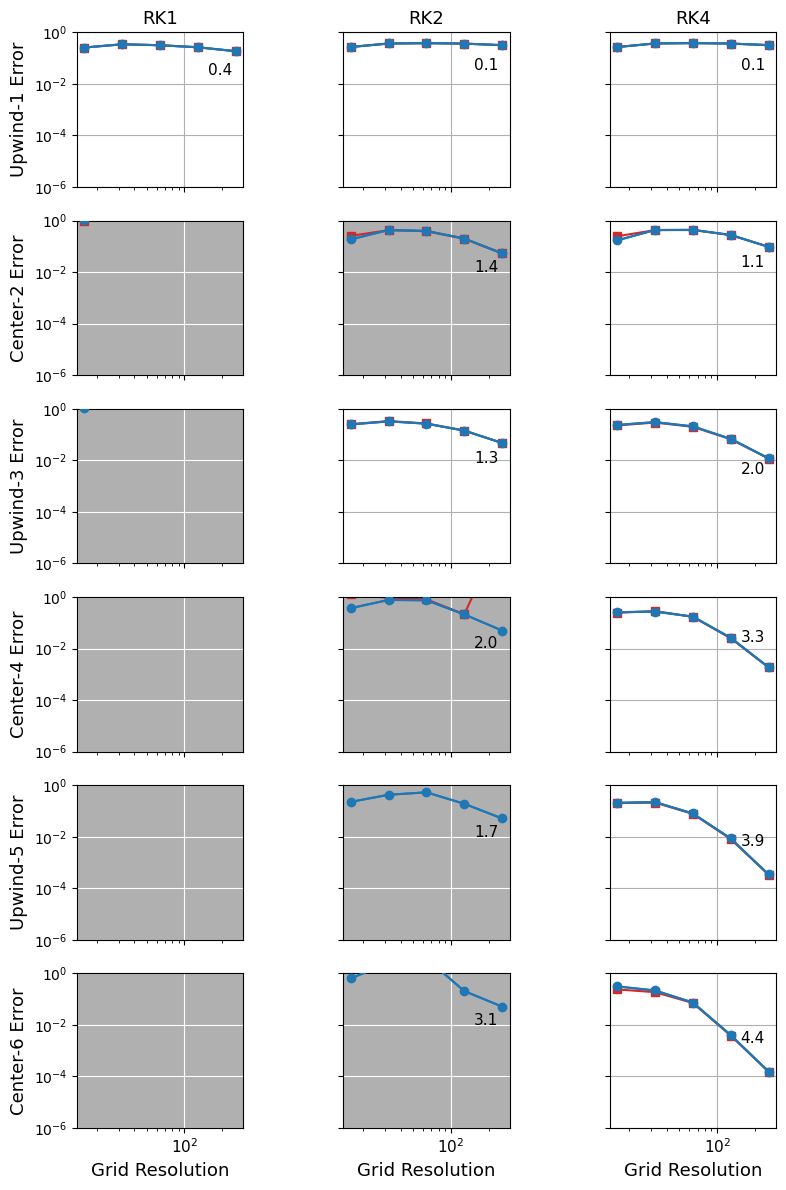

L1 ERROR: 1.0932481564504883 Maxwell Greater!


In [17]:
scootch = 0.6
x = 6 + (2 * scootch) + 0.1
y = 12
color1, color2, zorder1, zorder2, linestyle1, linestyle2, marker1, marker2, Advect, Maxwell, testName = GraphParams(Two, Uniform, AMR)
testName = testName + addOnStr
saveName = savePath + testName + saveAppend

# 6 columns, 3 rows → total 18 plots
if (rotate):
    rows = 3
    columns = 6
    figsize = (y, x)
    rotString = 'Rotated'
else:
    rows = 6
    columns = 3
    figsize = (x, y)
    rotString = ''
fig, axs = plt.subplots(rows, columns, figsize=figsize)#, constrained_layout=True)
if (test == 1):
    xLabel = 'Grid Resolution'
else:
    xLabel = 'Base Grid Resolution'

RK = 1
order = 1

err = 0

for ax in axs.T.flat:
    stable = Stability(RK, order)
    if (order % 2 == 0):
        preLabel = 'Center-'
    else:
        preLabel = 'Upwind-'
    print('RK:', RK, 'order:', order, 'stable:', stable)

    title = 'RK' + str(RK)
    yLabel = preLabel + str(order)

    

    if (order % 2 == 0):
        diff = 'CD'
    else:
        diff = 'UD'


    

    if (order == 1):
        print('Title!')
        if (rotate):
            ax.set_ylabel(title + ' Error', fontsize = 13)
            ax.tick_params(axis = 'y', labelsize = 10)
        else:
            ax.set_title(title, fontsize = 13) # Used to be 18.
    else:
        if (rotate):
            ax.tick_params(axis = 'y', labelleft = False)


    
    if (rotate):
        if (RK == 4):
            ax.set_xlabel(xLabel, fontsize = 13)
            ax.tick_params(axis = 'x', labelsize = 11)
            if (order != 1):
                ax.tick_params(axis = 'y', labelleft = False)
        else:
            ax.tick_params(axis = 'x', labelbottom = False)
    else:
        if (order == 6):
            ax.set_xlabel(xLabel, fontsize = 13)
            ax.tick_params(axis = 'x', labelsize = 11)
            if (RK != 1):
                ax.tick_params(axis = 'y', labelleft = False)
        else:
            ax.tick_params(axis = 'x', labelbottom = False)



            
    if (RK == 1):
        if (rotate):
            ax.set_title(yLabel, fontsize = 13)
        else:
            ax.set_ylabel(yLabel + ' Error', fontsize = 13)
            ax.tick_params(axis = 'y', labelsize = 10)
        if (order < 6):
            ax.tick_params(axis = 'x', labelbottom = False)
    else:
        if (not rotate):
            ax.tick_params(axis = 'y', labelleft = False)


    if (Fake):
        refLine1, refLine2, nhVec, slopeX, slopeY, slope = FakeData(nh_min, dataPts, order, RK)
    else:
        nhVec, refLine1 = WaveEqConvergenceTest(omega0, physics1, CFL, RK, order, diff, func, args, dataPts, AMR1, numRefCel = 4, plot = plot, derivative = derivative, scale = factor, AM = AM1, refRatio0 = refRatio1, nt = nt1, sameTime = sameTime, override = override)
        nhVec, refLine2 = WaveEqConvergenceTest(omega0, physics2, CFL, RK, order, diff, func, args, dataPts, AMR2, numRefCel = 4, plot = plot, derivative = derivative, scale = factor, AM = AM2, refRatio0 = refRatio2, nt = nt2, sameTime = sameTime, override = override)
    
    if np.any(refLine1 <= 0) or np.any(refLine2 <= 0):
        raise ValueError('Log scale can\'t handle non-positive data.')
    
    # line_kwargs = dict(linestyle=linestyle1, color=color1, zorder=zorder1)
    # marker_kwargs = dict(marker=marker1, linestyle='None', color=color1, zorder=zorder1)
    # ax.plot(nhVec, refLine1, **line_kwargs)
    # ax.plot(nhVec, refLine1, **marker_kwargs)
    ax.loglog(nhVec, refLine1, linestyle = linestyle1, color = color1, zorder = zorder1)
    ax.plot(nhVec, refLine1, linestyle = linestyle1, color = color1, zorder = zorder1, marker = marker1)
    ax.plot(nhVec, refLine2, linestyle = linestyle2, color = color2, zorder = zorder2, marker = marker2)
    # ax.yaxis.set_major_formatter(LogFormatter(labelOnlyBase=True))
    if (stable):
        difference = refLine1 / refLine2
        errNew = TT.VectorNorm(difference, 'L1')
        print('ERROR INFO:')
        print(difference)
        print(errNew)
        print('')
        err = err + errNew
    # if (errNew > err):
    #     err = errNew

    #slopeY = 0.31#05910838730198

    
    
    if (Fake):
        ax.text(slopeX, slopeY, str(slope), fontsize = 11, zorder = 4)
    else:
        slopeX1, slopeY1, slope1, slopeX2, slopeY2, slope2 = BothSlopes(nhVec, refLine1, refLine2, order)
        # if ((test == 3) and (order == 2) and (RK == 4) and (func == WFT.Gauss)):
        #     print('')
        #     print('!!!!!!!!!!!!!!!!!!!!!!!', slopeY1, '!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
        #     print('!!!!!!!!!!!!!!!!!!!!!!!', slopeY2, '!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
        #     print('')
        if (slopeY1 < 1):
            if (slopeY1 > 0.3):
                slopeY1 = 0.3
            ax.text(slopeX1, slopeY1, str(slope1), fontsize = 11, zorder = 4)
        if ((slope2 > 0) and (slopeY2 < 1)):
            if (slopeY2 > 0.3):
                slopeY2 = 0.3
            ax.text(slopeX2, slopeY2, str(slope2), fontsize = 11, zorder = 4)
    
    if (not stable):
        # rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes, facecolor='yellow', alpha=0.2, zorder=0, linewidth=0)
        rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes, facecolor='#b0b0b0', alpha=1, zorder=0, linewidth=0)
        ax.add_patch(rect)
        gridColor = 'white'
    else:
        gridColor = '#b0b0b0'
    #     # ax.set_facecolor('lightyellow')
    #     ax.set_facecolor('#b0b0b0')
    #     gridColor = 'white'
    #     # gridColor = '#b0b0b0'
    # else:
    #     gridColor = '#b0b0b0'
    ax.grid(True, zorder = 0, color = gridColor)
    ax.set_ylim([10**-6, 1])
    # ax.set_autoscale_on(False)
    if (rotate):
        if (RK < 4):
            RK = 2 * RK
        else:
            order = order + 1
            RK = 1
    else:
        if (order < 6):
            order = order + 1
        else:
            RK = 2 * RK
            order = 1
    # Ticks and spines are left on — this matches axs[1, 1]

plt.tight_layout()
if (not rotate):
    fig.subplots_adjust(wspace=scootch)
fig.subplots_adjust(right=1.07)  # nudges the right margin out
fig.savefig(saveName + rotString + '.png', bbox_inches = 'tight', dpi = 400, transparent = True)
plt.show()

err = err / 10


if (err > 1):
    if (test < 3):
        message = 'Advect Greater!'
    else:
        message = 'Uniform Greater!'
else:
    err = 1 / err
    if (test < 3):
        message = 'Maxwell Greater!'
    else:
        message = 'LMR Greater!'
print('L1 ERROR:', err, message)

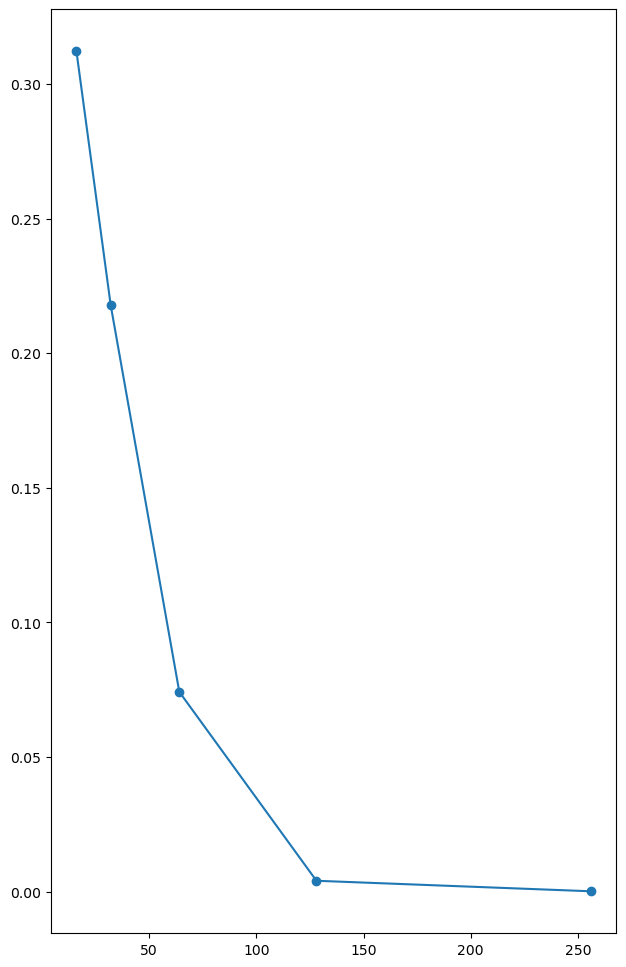

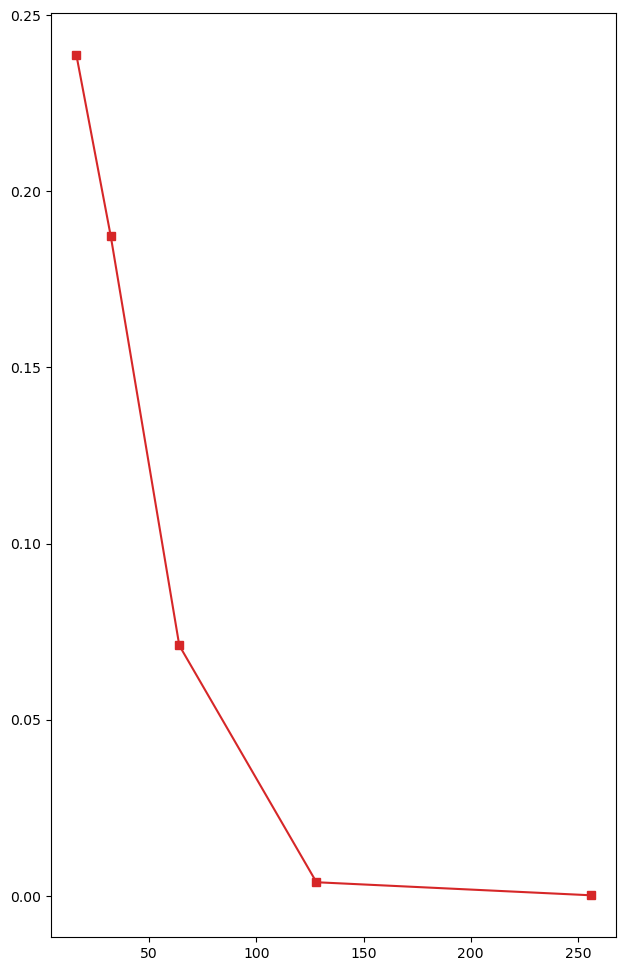

In [18]:
legends3 = []
labels3 = []

legends1 = []
labels1 = []
fig, ax = plt.subplots(figsize = figsize)
line1, = ax.plot(nhVec, refLine1, linestyle = linestyle1, color = color1, marker = marker1, label = '')
legends1.append(line1)
labels1.append('')
legends3.append(line1)
labels3.append(str1)
plt.show()

legends2 = []
labels2 = []
fig, ax = plt.subplots(figsize = figsize)
line2, = ax.plot(nhVec, refLine2, linestyle = linestyle2, color = color2, marker = marker2, label = '')
legends2.append(line2)
labels2.append('')
legends3.append(line2)
labels3.append(str2)
plt.show()

In [19]:
legFig1 = plt.figure()
leg1 = legFig1.legend(legends1, labels1, loc='center')
leg1.get_frame().set_alpha(0.0)
saveName = savePath + testName + 'Legend1'
legFig1.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()

<Figure size 640x480 with 0 Axes>

In [20]:
legFig2 = plt.figure()
leg2 = legFig2.legend(legends2, labels2, loc='center')
leg2.get_frame().set_alpha(0.0)
saveName = savePath + testName + 'Legend2'
legFig2.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()

<Figure size 640x480 with 0 Axes>

In [21]:
legFig3 = plt.figure()
leg3 = legFig3.legend(legends3, labels3, loc='center')
# leg1.get_frame().set_alpha(0.0)
saveName = savePath + testName + 'Legend' + rotString
legFig3.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
a = 5.5
b = 5.6
print(math.isclose(a, b, abs_tol = 0.1))

True


In [23]:
default_grid_color = plt.rcParams['grid.color']
print(default_grid_color)

#b0b0b0


In [24]:
print(ax.get_yticks())
print('')

[-0.05                 0.                   0.05                 0.10000000000000002  0.15000000000000002  0.2                  0.25000000000000006  0.30000000000000004]



In [25]:
difference = (np.log(10000) - np.log(10)) / np.log(10)
print(difference)
print('')

3.0

